# Summative Lab – Analytics Firm Clients: Customer Reviews Analysis

This notebook is a **starter notebook** for the three parts of the lab:

1. NLP  
2. Time Series  
3. Neural Networks  

Use the comments and TODO prompts to guide your work. The notebook is intentionally incomplete so you can implement the analysis yourself.


## Part 1: NLP

In this section, you will clean and preprocess review text, explore frequent words and bigrams, and visualize key language patterns in the dataset.


In [6]:
# =========================
# Part 1: NLP Starter Code
# =========================

# TODO: Import the libraries you need for:
# - data handling
# - plotting
# - text preprocessing
# - tokenization / stopwords / lemmatization
# - counting words and bigrams

# Example:
# import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams

# TODO: Download any required NLTK resources.
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Nathan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Nathan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nathan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Nathan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [11]:
# TODO: Load the dataset.
# Hint: The file used in this lab is 'amazon_reviews_lab.csv'
# df = ...
df = pd.read_csv('amazon_reviews_lab.csv')


# TODO: Explore the dataset.
# Suggested checks:
# - shape
# - value counts for the rating column
# - preview the first few rows
print("Dataset shape:", df.shape)
print("\nRating distribution:")
df['rating'].value_counts().sort_index()
print("\nFirst few rows:")
df.head()

Dataset shape: (997, 9)

Rating distribution:

First few rows:


,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,This film is definitely not for anyone who is ...,The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,2000-05-12,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hal...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,2002-08-26,positive,168
2,6301977173,1,I would love to buy this movie as I have been ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,2005-08-06,negative,60
3,6301977173,1,The advertisment for this DVD on Amazon was in...,False advertising on this DVD,"09 11, 2005",1.126397e+09,2005-09-11,negative,104
4,9575871979,5,I bought some of these to try with a light usi...,Work GREAT!!,"10 15, 2007",1.192406e+09,2007-10-15,positive,60


In [16]:
# TODO: Write a function called preprocess_text(text) that:
def preprocess_text(text):
# 1. converts text to lowercase
    text = str(text).lower()
# 2. removes URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
# 3. removes punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
# 4. tokenizes the text
    tokens = word_tokenize(text)
# 5. keeps alphabetic tokens only
    tokens = [t for t in tokens if t.isalpha()]
# 6. removes stopwords
    tokens = [t for t in tokens if t not in stop_words]
# 7. lemmatizes the remaining tokens
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
# 8. returns the cleaned tokens
    return tokens

In [14]:
# TODO: Apply your preprocessing function to the review text column
# and store the output in a new column such as 'processed_tokens'.
df['processed_tokens'] = df['review_text'].apply(preprocess_text)


# TODO: Combine all tokens into one list so you can compute word frequencies.
all_tokens = [token for tokens in df['processed_tokens'] for token in tokens]


# TODO: Use Counter to identify the most common words.
word_counts = Counter(all_tokens)
print("Top 20 Most Common Words:")
top_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Count'])
top_words['Rank'] = range(1, 21)
top_words[['Rank', 'Word', 'Count']]

Top 20 Most Common Words:


,Rank,Word,Count
0,1,nook,1509
1,2,book,913
2,3,one,569
3,4,kindle,561
4,5,screen,496
5,6,like,459
6,7,read,454
7,8,work,446
8,9,get,424
9,10,great,422


In [20]:
# TODO: Generate bigrams from the token list and identify the most common bigrams.
bigram_counts = Counter(ngrams(all_tokens, 2))
print("Top 20 Most Common Bigrams:")
top_bigrams = pd.DataFrame([(' '.join(b), c) for b, c in bigram_counts.most_common(20)], columns=['Bigram', 'Count'])
top_bigrams['Rank'] = range(1, 21)
top_bigrams[['Rank', 'Bigram', 'Count']]

Top 20 Most Common Bigrams:


,Rank,Bigram,Count
0,1,barnes noble,152
1,2,nook color,127
2,3,battery life,87
3,4,touch screen,81
4,5,sd card,80
5,6,nook hd,74
6,7,work great,63
7,8,nook tablet,63
8,9,work well,57
9,10,read book,55


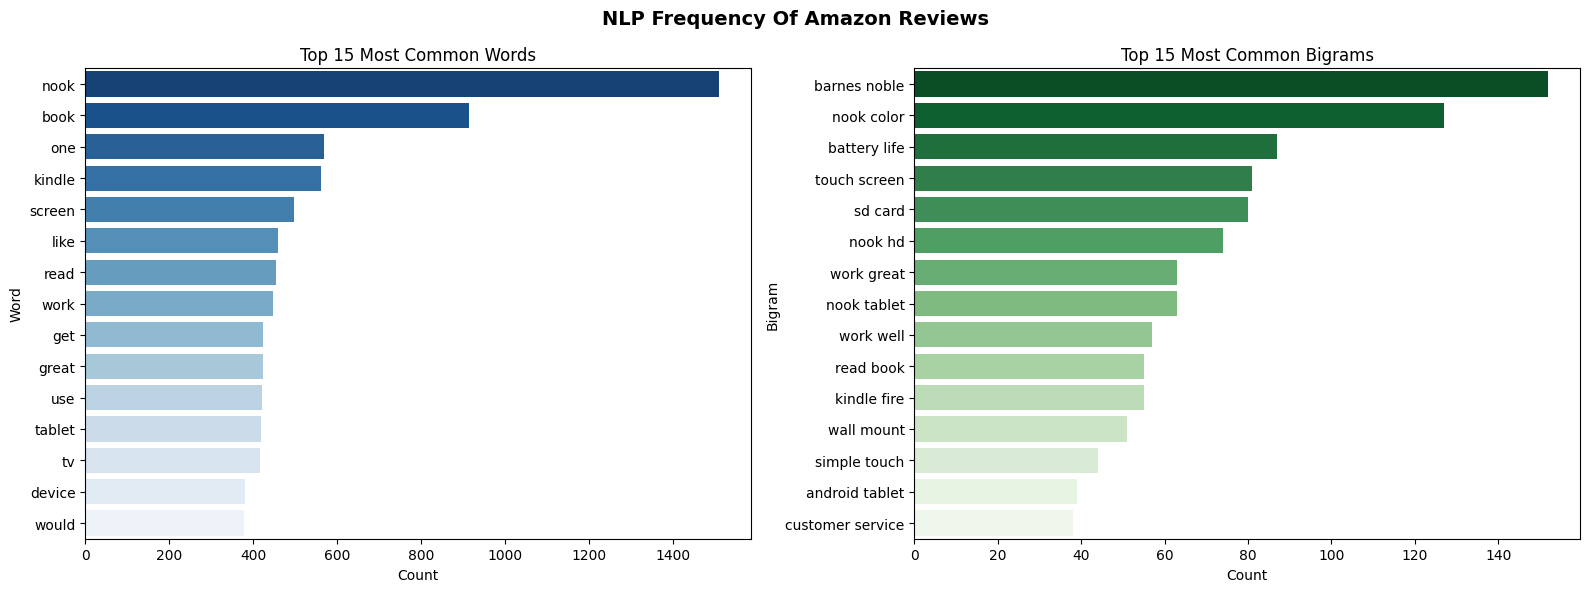

In [25]:
# TODO: Create at least one visualization of the most common words.
# You may also choose to visualize the most common bigrams.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

common_words = pd.DataFrame(word_counts.most_common(15), columns=['word', 'count'])
sns.barplot(data=common_words, x='count', y='word', hue='word', palette='Blues_r', ax=axes[0], legend=False)
axes[0].set_title('Top 15 Most Common Words')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Word')

common_bigrams = pd.DataFrame([(' '.join(b), c) for b, c in bigram_counts.most_common(15)], columns=['bigram', 'count'])
sns.barplot(data=common_bigrams, x='count', y='bigram', hue='bigram', palette='Greens_r', ax=axes[1], legend=False)
axes[1].set_title('Top 15 Most Common Bigrams')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Bigram')

plt.suptitle('NLP Frequency Of Amazon Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

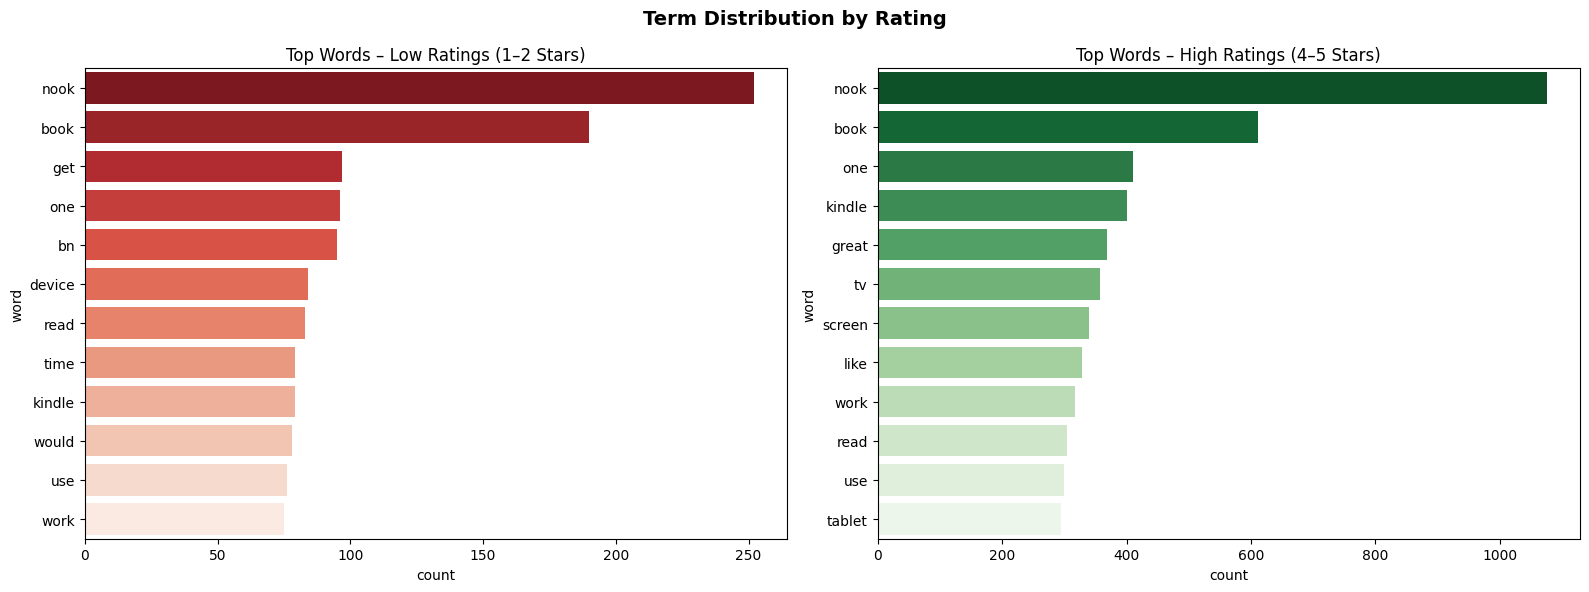

In [26]:
# Extra Meaningful Visuals
neg_tokens = [t for tokens, r in zip(df['processed_tokens'], df['rating'])
              for t in tokens if r <= 2]
pos_tokens = [t for tokens, r in zip(df['processed_tokens'], df['rating'])
              for t in tokens if r >= 4]

neg_counts = Counter(neg_tokens)
pos_counts = Counter(pos_tokens)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
neg_df = pd.DataFrame(neg_counts.most_common(12), columns=['word', 'count'])
sns.barplot(data=neg_df, x='count', y='word', hue='word', palette='Reds_r', ax=axes[0], legend=False)
axes[0].set_title('Top Words – Low Ratings (1–2 Stars)')

pos_df = pd.DataFrame(pos_counts.most_common(12), columns=['word', 'count'])
sns.barplot(data=pos_df, x='count', y='word', hue='word', palette='Greens_r', ax=axes[1], legend=False)
axes[1].set_title('Top Words – High Ratings (4–5 Stars)')

plt.suptitle('Term Distribution by Rating', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Reflection prompt:
#### What do the most common words or phrases suggest about customer sentiment or product experience?
The most commons works were nook, book, kindle and screen which all correlate to customer reviews of e-erader and tablet products. They have a lot of description features which means they focus on the product rather than the general topic.
There is a lot of shared words between high rating and low rating which means the reviews vary from customer to customer.

## Part 2: Time Series

In this section, you will analyze review activity over time by converting timestamps, resampling the data, and visualizing trends in review volume and ratings.


In [46]:
# ==============================
# Part 2: Time Series Starter Code
# ==============================

# TODO: Import the libraries you need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error

# TODO: Load the same review dataset
df = pd.read_csv('amazon_reviews_lab.csv')

In [28]:
# TODO: Convert the timestamp column to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# TODO: Inspect the date range in the dataset
# Suggested checks:
# - earliest timestamp
# - latest timestamp
print("Earliest review:", df['timestamp'].min())
print("Latest review:  ", df['timestamp'].max())
print("Total reviews:  ", len(df))

Earliest review: 2000-05-12 00:00:00
Latest review:   2014-07-17 00:00:00
Total reviews:   997


In [32]:
# TODO: Resample the data by month to calculate:
# Suggested variable names:
# monthly_review_count = ...
# monthly_avg_rating = ...

monthly_review_count = df.resample('ME', on='timestamp').size()
monthly_avg_rating   = df.resample('ME', on='timestamp')['rating'].mean()
monthly_avg_rating_clean = monthly_avg_rating.dropna()

# 1. monthly review count
print("Monthly Review Count (sample):")
count_df = monthly_review_count[monthly_review_count > 0].reset_index()
count_df.columns = ['Month', 'Review Count']
count_df

Monthly Review Count (sample):


,Month,Review Count
0,2000-05-31,1
1,2002-08-31,1
2,2005-08-31,1
3,2005-09-30,1
4,2007-10-31,1
...,...,...
63,2014-03-31,30
64,2014-04-30,22
65,2014-05-31,12
66,2014-06-30,15


In [33]:
# 2. monthly average rating
print("Monthly Average Rating (sample):")
rating_df = monthly_avg_rating_clean.reset_index()
rating_df.columns = ['Month', 'Avg Rating']
rating_df['Avg Rating'] = rating_df['Avg Rating'].round(2)
rating_df

Monthly Average Rating (sample):


,Month,Avg Rating
0,2000-05-31,2.00
1,2002-08-31,5.00
2,2005-08-31,1.00
3,2005-09-30,1.00
4,2007-10-31,5.00
...,...,...
63,2014-03-31,4.33
64,2014-04-30,4.00
65,2014-05-31,4.25
66,2014-06-30,4.53


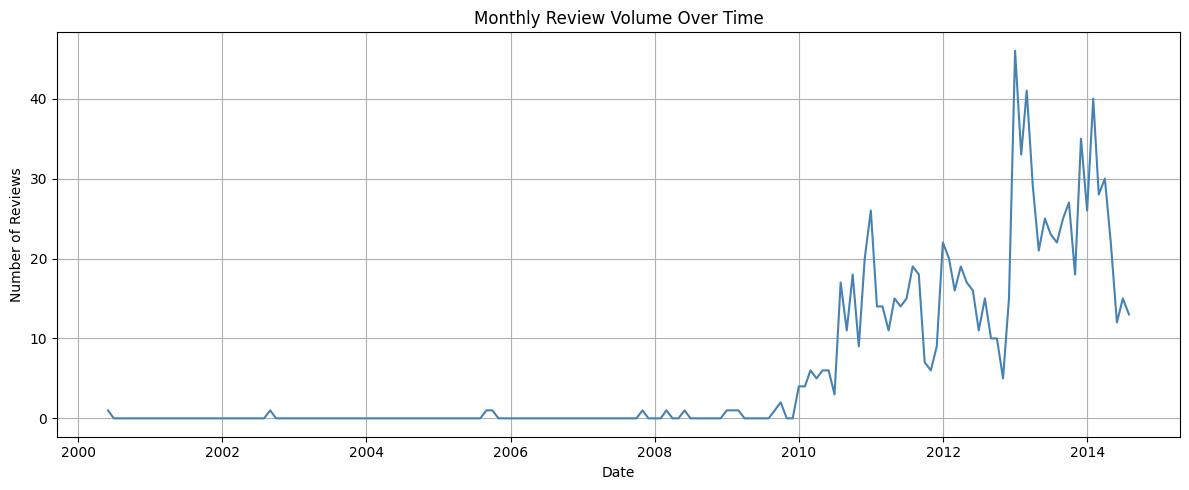

In [34]:
# TODO: Plot monthly review volume over time.
plt.figure(figsize=(12, 5))
plt.plot(monthly_review_count.index, monthly_review_count.values, color='steelblue')
plt.title('Monthly Review Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.tight_layout()
plt.show()

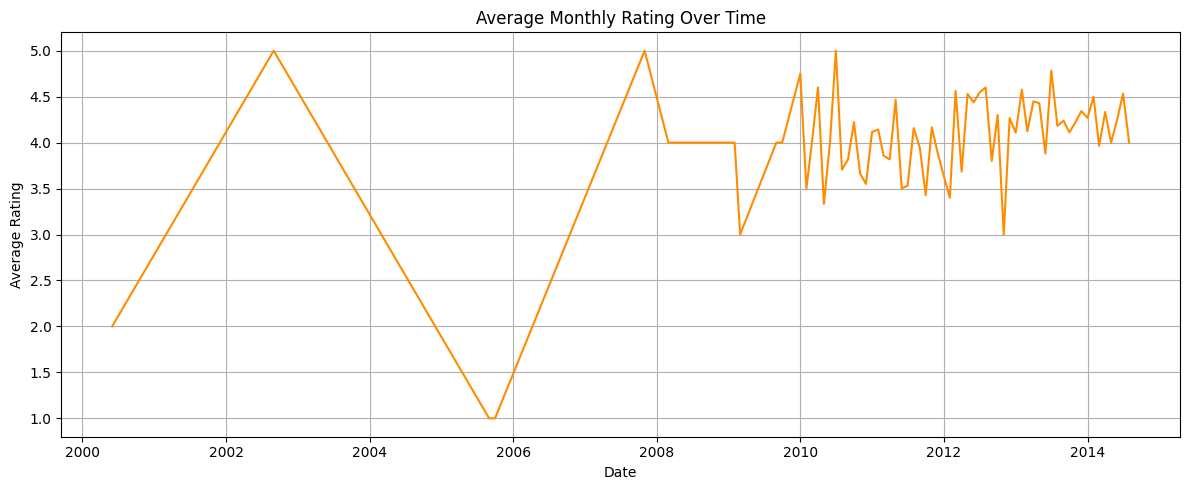

In [35]:
# TODO: Plot average monthly rating over time
plt.figure(figsize=(12, 5))
plt.plot(monthly_avg_rating_clean.index, monthly_avg_rating_clean.values, color='darkorange')
plt.title('Average Monthly Rating Over Time')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
# TODO: Compute a rolling average for the monthly average rating.
# A 3-month rolling average is a good starting point.
rolling_avg = monthly_avg_rating_clean.rolling(window=3).mean()

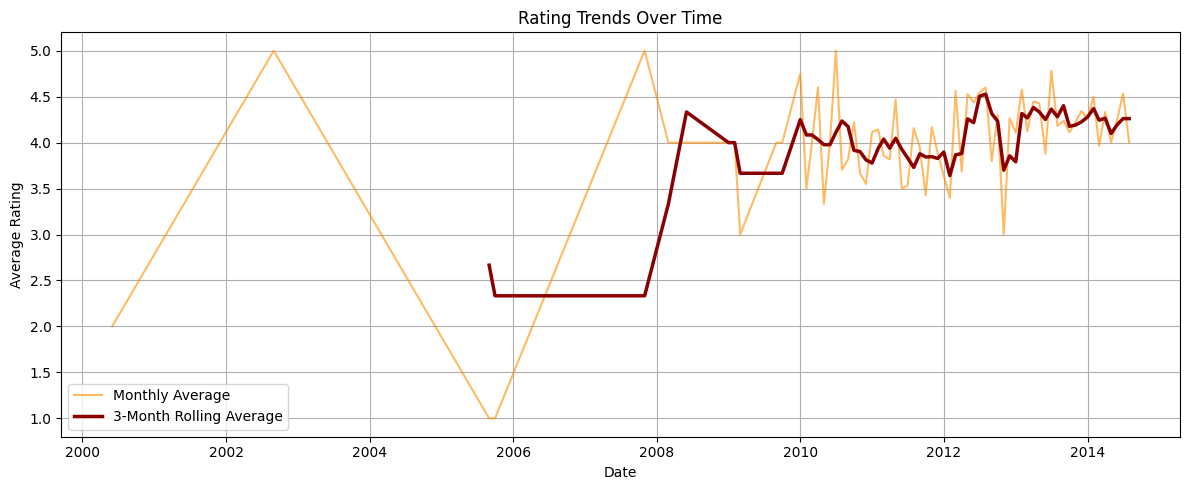

In [38]:
# TODO: Compute a rolling average for the monthly average rating.
# A 3-month rolling average is a good starting point.
rolling_avg = monthly_avg_rating_clean.rolling(window=3).mean()

# TODO: Plot both:
# - the original monthly average rating
# - the rolling average
# on the same figure.
plt.figure(figsize=(12, 5))
plt.plot(monthly_avg_rating_clean.index, monthly_avg_rating_clean.values,
         label='Monthly Average', alpha=0.6, color='darkorange')
plt.plot(rolling_avg.index, rolling_avg.values,
         label='3-Month Rolling Average', linewidth=2.5, color='darkred')
plt.title('Rating Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

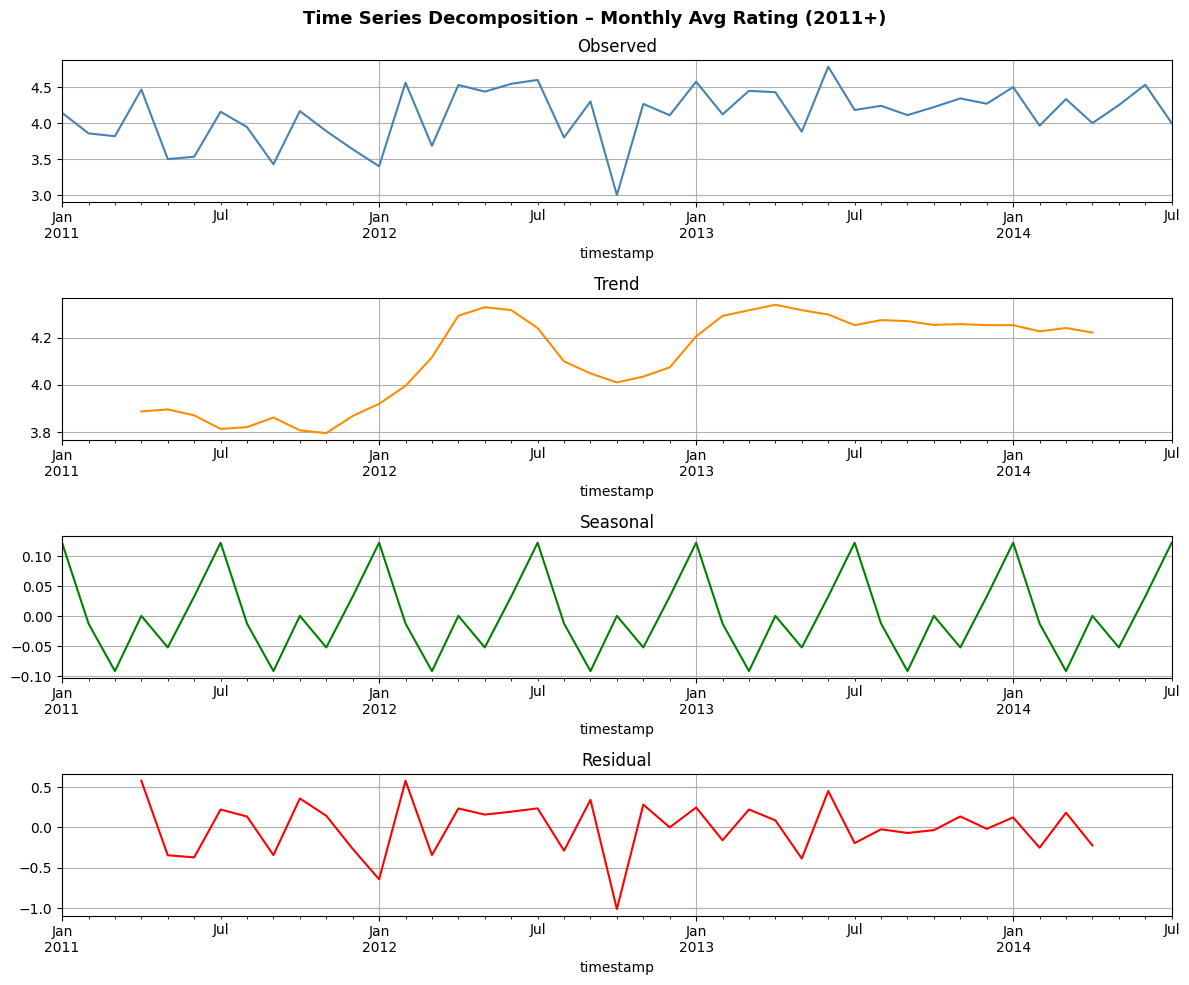

In [47]:
#More comparison Models- time series decomposition
# Break the series into trend, seasonality, and residual components
dense_series = monthly_avg_rating_clean['2011':]

decomposition = seasonal_decompose(dense_series, model='additive', period=6)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=axes[0], title='Observed',  color='steelblue')
decomposition.trend.plot(ax=axes[1],    title='Trend',     color='darkorange')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal',  color='green')
decomposition.resid.plot(ax=axes[3],    title='Residual',  color='red')
for ax in axes:
    ax.grid(True)
plt.suptitle('Time Series Decomposition – Monthly Avg Rating (2011+)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

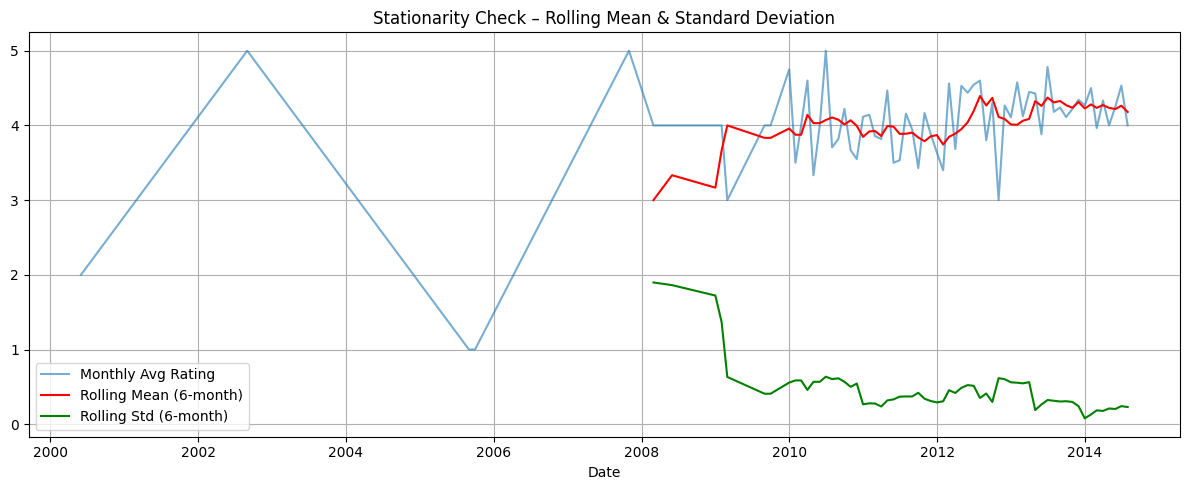


ADF Test – Original Series
  ADF Statistic : -1.4557
  p-value       : 0.5553
  Critical (5%) : -2.9138
  >> NON-STATIONARY (fail to reject H0) — transformation needed

ADF Test – Log-Transformed Series
  ADF Statistic : -1.6209
  p-value       : 0.4723
  Critical (5%) : -2.9138
  >> NON-STATIONARY (fail to reject H0) — transformation needed

ADF Test – First-Differenced Series
  ADF Statistic : -5.4645
  p-value       : 0.0000
  Critical (5%) : -2.9138
  >> STATIONARY (reject H0)

ADF Test – Log + Differenced Series
  ADF Statistic : -6.1940
  p-value       : 0.0000
  Critical (5%) : -2.9138
  >> STATIONARY (reject H0)


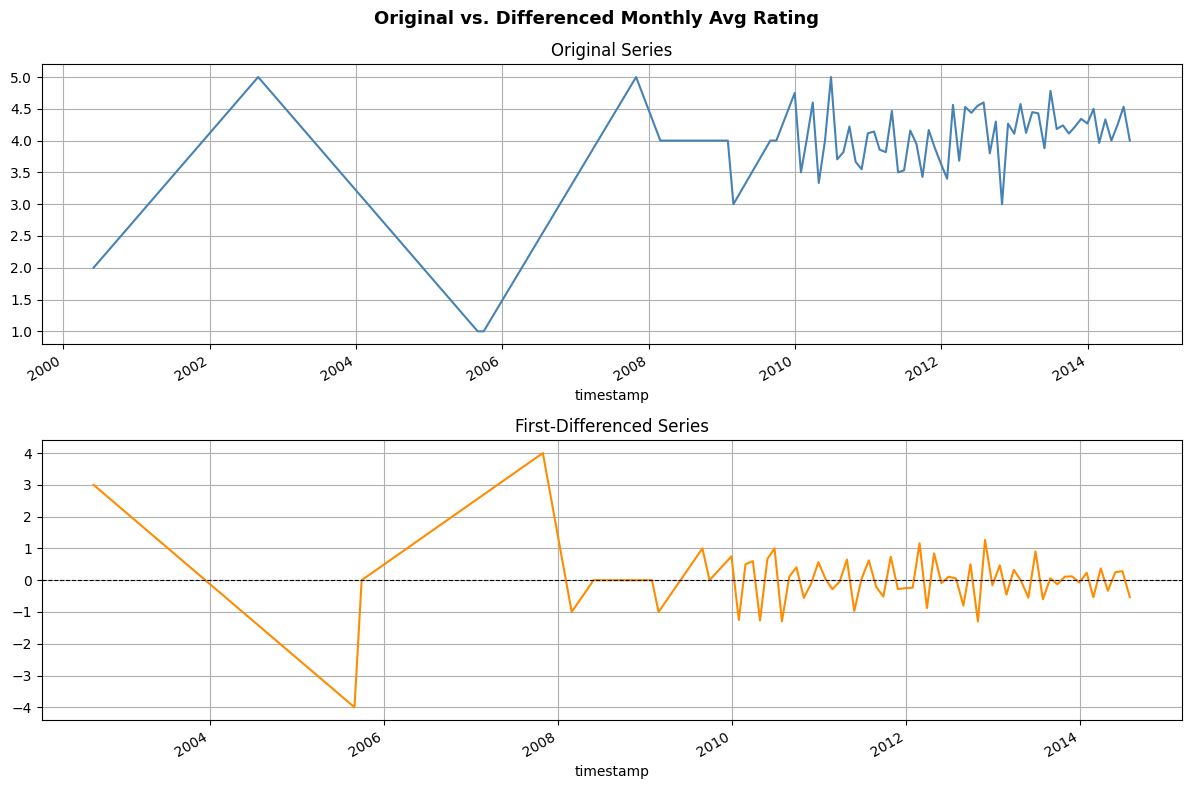

In [49]:
#More comparison Models- stationarity check + ADF + transformations
series = monthly_avg_rating_clean.copy()

# Visual check: rolling mean and std
roll_mean = series.rolling(window=6).mean()
roll_std  = series.rolling(window=6).std()

plt.figure(figsize=(12, 5))
plt.plot(series,    label='Monthly Avg Rating',     alpha=0.6)
plt.plot(roll_mean, label='Rolling Mean (6-month)', color='red')
plt.plot(roll_std,  label='Rolling Std (6-month)',  color='green')
plt.title('Stationarity Check – Rolling Mean & Standard Deviation')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ADF Test helper function
def run_adf(series, label='Series'):
    result = adfuller(series.dropna())
    print(f"\nADF Test – {label}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Critical (5%) : {result[4]['5%']:.4f}")
    if result[1] < 0.05:
        print("  >> STATIONARY (reject H0)")
    else:
        print("  >> NON-STATIONARY (fail to reject H0) — transformation needed")

# Test original, log, differenced, and log+diff series
run_adf(series,                        'Original Series')
run_adf(np.log(series),               'Log-Transformed Series')
run_adf(series.diff().dropna(),        'First-Differenced Series')
run_adf(np.log(series).diff().dropna(),'Log + Differenced Series')

# Plot original vs differenced
diff_series = series.diff().dropna()
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
series.plot(ax=axes[0], title='Original Series', color='steelblue')
axes[0].grid(True)
diff_series.plot(ax=axes[1], title='First-Differenced Series', color='darkorange')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].grid(True)
plt.suptitle('Original vs. Differenced Monthly Avg Rating',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Reflection prompt:
#### What overall trends do you notice in review activity and customer ratings over time?
The review activity increased significantly over time, especially after 2010, showing growing customer engagement and more frequent monthly reviews.
Customer ratings generally remained stable and positive, with most average ratings staying around 4 to 4.5 stars despite some fluctuations.
The decomposition and stationarity analysis also suggest a slight upward trend in ratings over time along with small seasonal patterns and occasional irregular changes in customer sentiment.

## Part 3: Neural Networks

In this section, you will transform text reviews into numerical features, train a neural network to predict ratings, and evaluate model performance.


In [56]:
# ===================================
# Part 3: Neural Networks Starter Code
# ===================================

# TODO: Import the libraries you need for:
# - data handling
# - train/test splitting
# - text vectorization
# - model building
# - model evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from keras import layers
from tensorflow.keras.utils import to_categorical

# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [57]:
# TODO: Load the dataset.
# df = ...
df = pd.read_csv('amazon_reviews_lab.csv')
# TODO: Define:
# X as the review text column
X = df['review_text'].astype(str)
# y as the rating column
y = df['rating'] - 1
# If needed, adjust y so the classes are numbered appropriately for your model.


# TODO: Vectorize the text using TF-IDF.
# Suggested question:
# - How many features do you want to keep?
# vectorizer = ...
# X_tfidf = ...
vectorizer = TfidfVectorizer(max_features=2000, stop_words='english')
X_tfidf = vectorizer.fit_transform(X).toarray()


# TODO: Split the data into training and testing sets.
# Use stratify=y to preserve class balance.
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)


# TODO: One-hot encode the target values if your neural network setup requires it.
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat  = to_categorical(y_test,  num_classes=5)


# TODO: Build a neural network model.
# Include:
# - an input layer
# - at least one hidden layer
# - an output layer suitable for multi-class classification
# model = ...
model1 = keras.Sequential([
    layers.Dense(128, activation='relu', 
    input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(5, activation='softmax')
], name='Baseline_Model')


# TODO: Compile the model.
# Think about:
# - optimizer
# - loss function
# - evaluation metric(s)
model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model1.summary()

C:\Users\Nathan\miniconda3\envs\pytorch_labs\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 128)                 │         256,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 264,709 (1.01 MB)

 Trainable params: 264,709 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
# TODO: Train the model and store the training history.
# history = ...
history1 = model1.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)
model1.summary()

#model number 2
model2 = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(5, activation='softmax')
], name='Deeper_Model')
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model2.summary()
history2 = model2.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=15,
    batch_size=16,
    verbose=1
)


# TODO: Evaluate the model on the test set.
loss1, acc1 = model1.evaluate(X_test, y_test_cat, verbose=0)
loss2, acc2 = model2.evaluate(X_test, y_test_cat, verbose=0)

eval_df = pd.DataFrame({
    'Model': ['Model 1 – Baseline', 'Model 2 – Deeper'],
    'Test Accuracy': [round(acc1, 4), round(acc2, 4)],
    'Test Loss': [round(loss1, 4), round(loss2, 4)]
})
eval_df


# TODO: Generate predictions on the test set.
best_nn = model1 if acc1 >= acc2 else model2
print(f"\nUsing {'Model 1 (Baseline)' if acc1 >= acc2 else 'Model 2 (Deeper)'} for final evaluation\n")
y_pred = best_nn.predict(X_test).argmax(axis=1)


# TODO: Create a classification report and/or confusion matrix to assess performance.
print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['1 Star','2 Stars','3 Stars','4 Stars','5 Stars']
))

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 8.5799e-04 - val_accuracy: 0.5188 - val_loss: 2.3473
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 6.4769e-04 - val_accuracy: 0.5188 - val_loss: 2.3620
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 8.4167e-04 - val_accuracy: 0.5188 - val_loss: 2.3669
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 6.2717e-04 - val_accuracy: 0.5250 - val_loss: 2.3788
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 5.8491e-04 - val_accuracy: 0.5250 - val_loss: 2.3929
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 6.1148e-04 - val_accuracy: 0.5250 - val_loss: 2.4087
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 4.7035e-04 - val_accuracy: 0.5250 - val_loss: 2.4087
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 6.1427e-04 - 

Model: "Baseline_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 128)                 │         256,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 794,129 (3.03 MB)

 Trainable params: 264,709 (1.01 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                     │ (None, 256)                 │         512,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 553,733 (2.11 MB)

 Trainable params: 553,733 (2.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5683 - loss: 1.3251 - val_accuracy: 0.5813 - val_loss: 1.2156
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5824 - loss: 1.0508 - val_accuracy: 0.5813 - val_loss: 1.1848
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5918 - loss: 0.8756 - val_accuracy: 0.5750 - val_loss: 1.1798
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7316 - loss: 0.6304 - val_accuracy: 0.5750 - val_loss: 1.3046
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8462 - loss: 0.4076 - val_accuracy: 0.5500 - val_loss: 1.4393
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9074 - loss: 0.2514 - val_accuracy: 0.5562 - val_loss: 1.6541
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9702 - loss: 0.1344 - val_accuracy: 0.5500 - val_loss: 1.9066
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9953 - loss: 0.0594 - val_accuracy: 0.5312 - val_loss:

## Reflection prompt:
#### Which rating classes does the model predict well, and which ones are harder to classify?
The first model shows 5 star rating class show highest precision, recall and f1 score. While this is because it makes up most of the data set, this gives the first model more 5 star examples to learn from. The harder class to classify is the 1,2 and 3 stars because of the low support and scores all around in precision, recall and f1. With 3 stars being the hardest to classify, the model most likely can only distinguish bad or good reviews and not neutral ones.